In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from matplotlib.animation import FuncAnimation
from IPython.display import HTML # libreria necesaria para mostrar las animaciones en google colab
import matplotlib as mpl
from mpl_toolkits.mplot3d import Axes3D
import plotly.graph_objects as go

#vamos a usar rk4 para todos los ejercicios
def rk4(f, xi, yi, paso):
  k1 = f(xi, yi)
  k2 = f(xi + 0.5*paso, yi + 0.5*paso*k1)
  k3 = f(xi + 0.5*paso, yi + 0.5*paso*k2)
  k4 = f(xi * paso, yi + paso*k3)
  return yi + paso*(k1 + 2*k2 + 2*k3 + k4)/6

g = 9.81

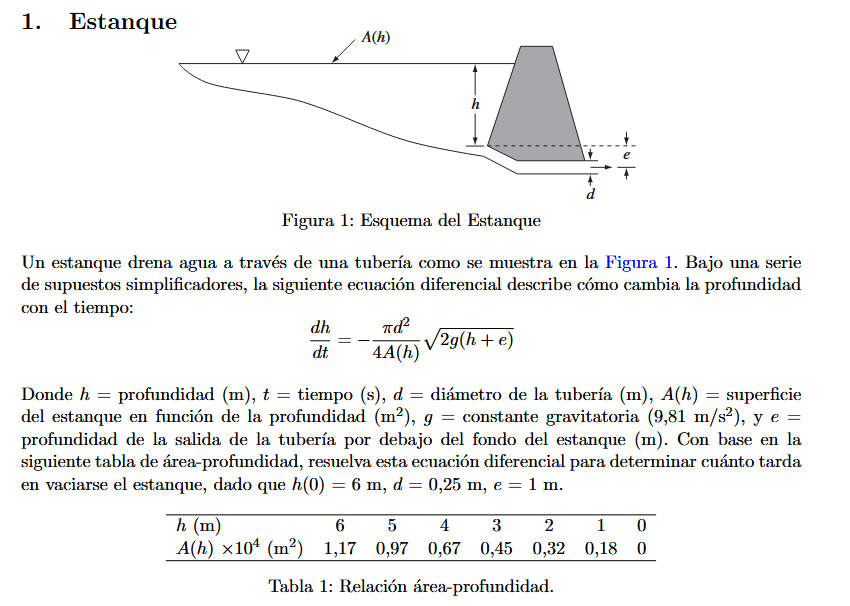
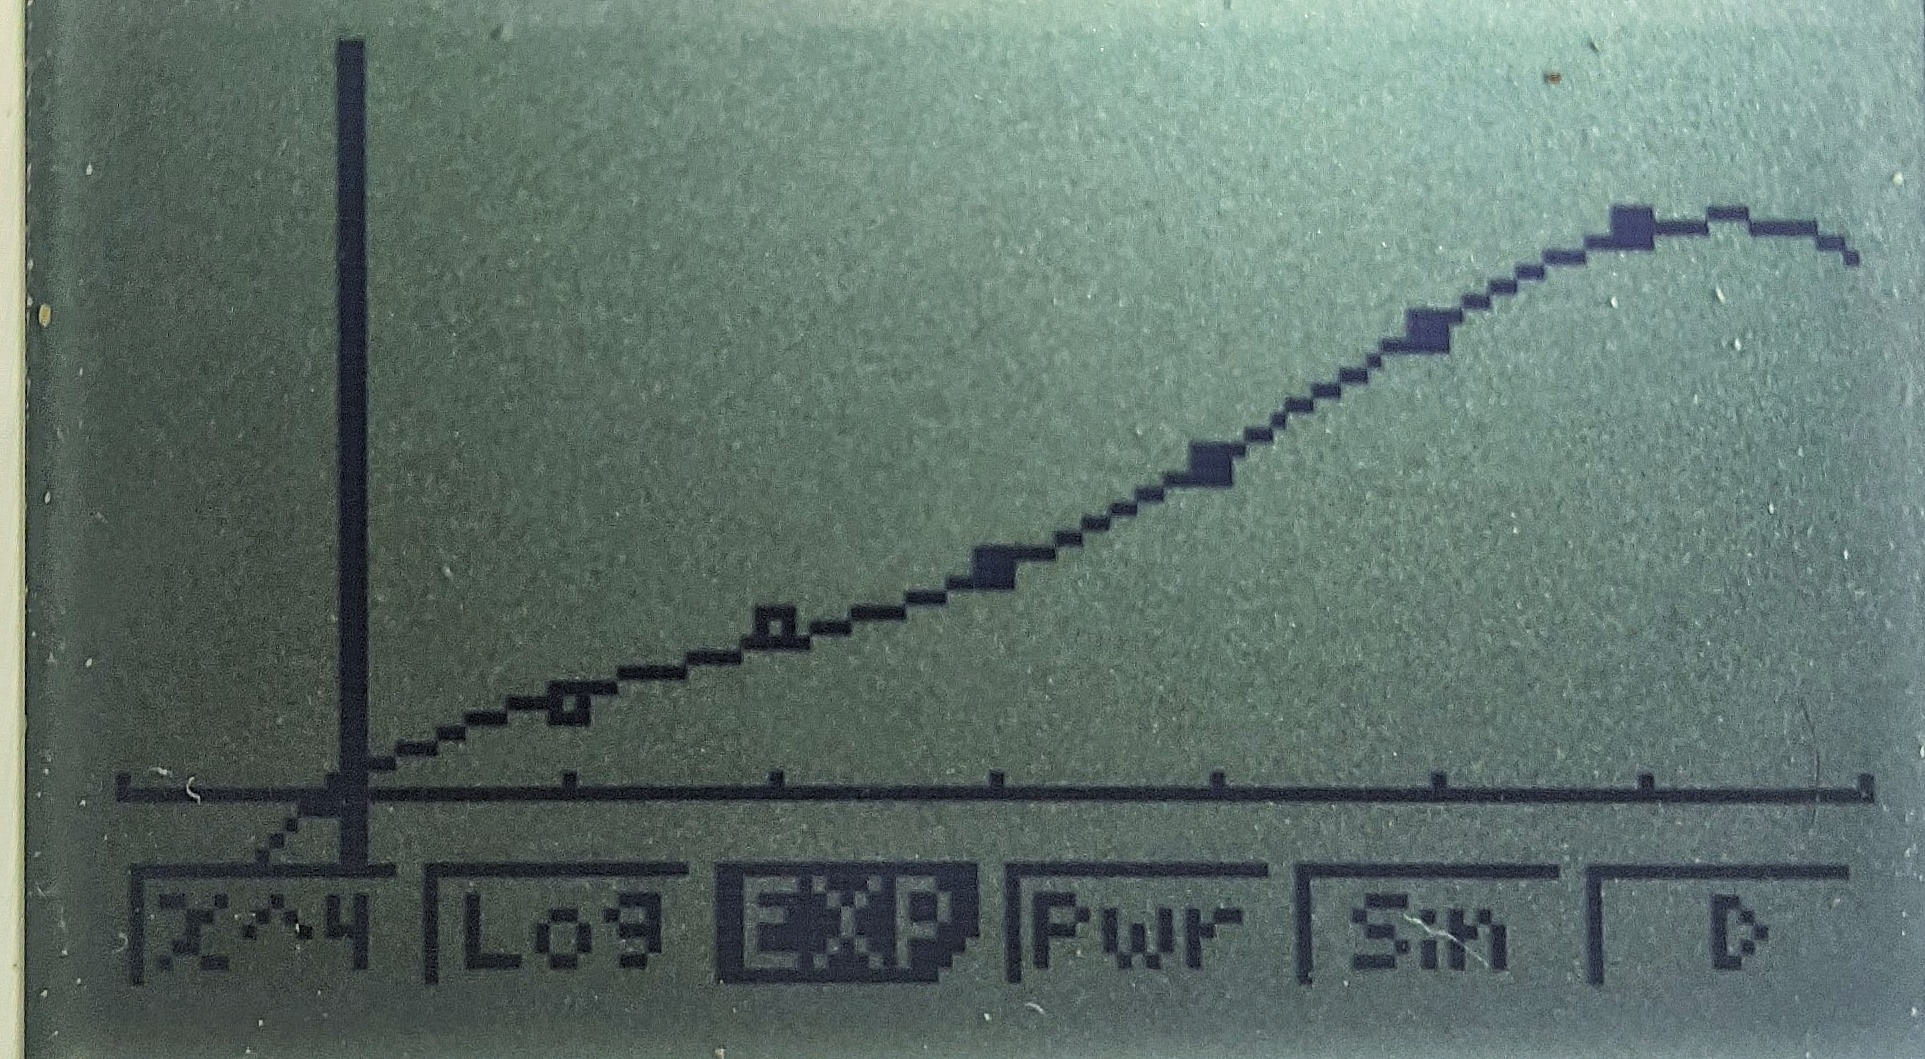

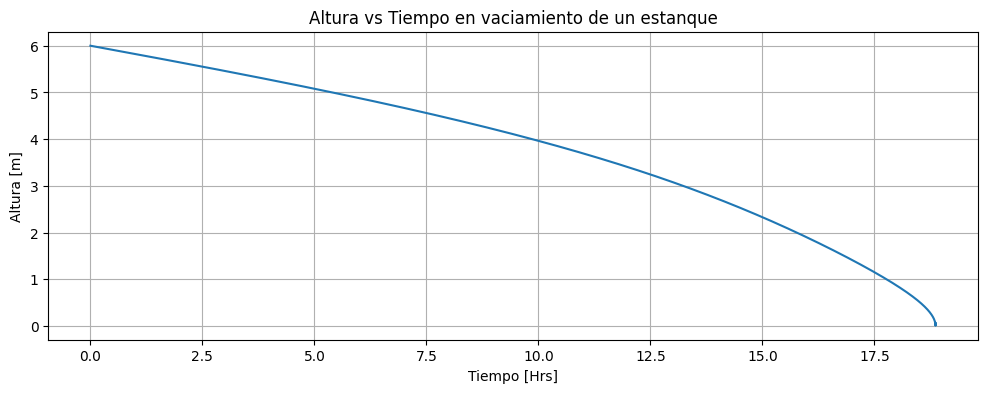

El estanque tarda 18.0 horas en vaciarse


In [ ]:
#usando la función regresión en la calculadora se encuentran las constantes de la formula de A(h) con forma elevada a 4 (ax4 + bx3 + cx2 + dx + e):
# r2 = 0.99934
def area(h):
  a = -32.196969
  b = 394.696969
  c = -1376.8939
  d = 2966.342
  e = -29.8710129
  return a*h**4 + b*h**3 + c*h**2 + d*h + e

#constantes
d = 0.25 #[m]
e = 1 #[m]

#valores iniciales
x_inicial = 0
y_inicial = np.array([6]) #[m]
y_final = 0
paso = 10 #[s]

#funcion a resolver
def funcion(x, y):
  altura = y[0]
  A = area(altura)
  primer_termino = (np.pi*(d**2))/(4*A)
  segundo_termino = np.sqrt(2*g*(altura + e))
  return -primer_termino*segundo_termino

#solver para este ejercicio
def calcular_parametros(f, xi, yi, yf, paso):
  y_lista = []
  x_lista = []
  while yi[0] > yf:
    y_lista.append(yi)
    x_lista.append(xi)
    yi = rk4(f, xi, yi, paso)
    xi += paso

  return np.array(x_lista), np.array(y_lista)

x_lista, y_lista = calcular_parametros(funcion, x_inicial, y_inicial, y_final, paso)

plt.figure(figsize=(12, 4))
plt.plot(x_lista/3600, y_lista)
plt.title('Altura vs Tiempo en vaciamiento de un estanque')
plt.ylabel('Altura [m]')
plt.xlabel('Tiempo [Hrs]')
plt.grid()
plt.show()

tiempo_total = x_lista[-1]/3600
print(f"El estanque tarda {np.trunc(tiempo_total)} horas en vaciarse")

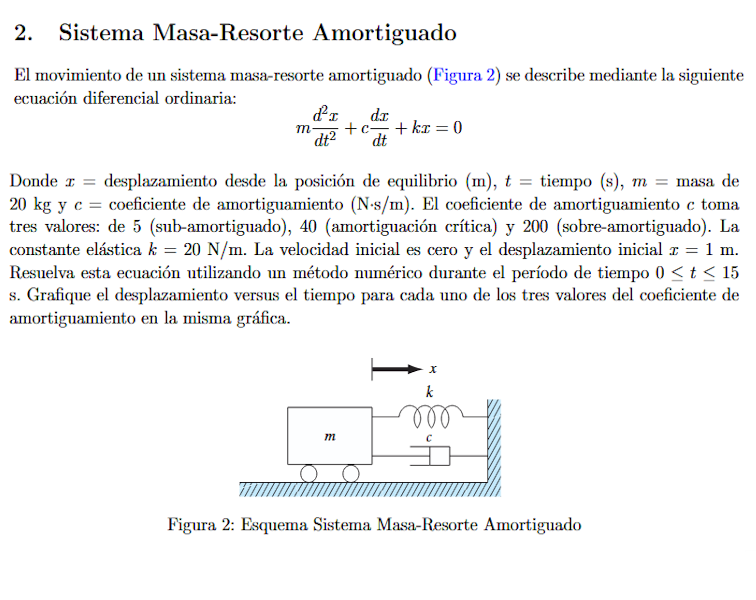

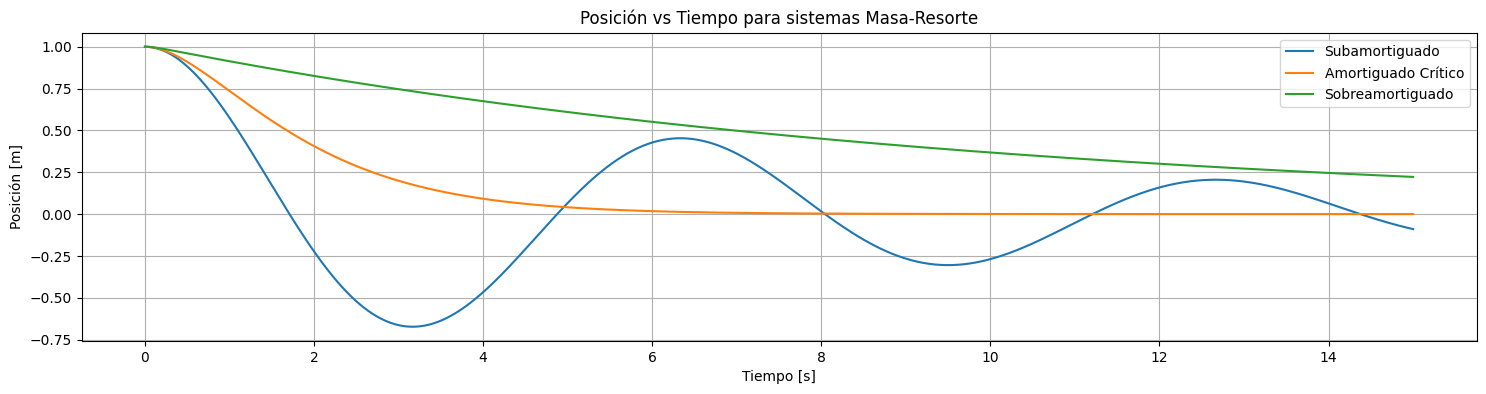

In [ ]:
t_paso = 0.01 #[s]
t_inicial = 0 #[s]
t_final = 15 #[s]
y_inicial = np.array([1, 0]) #posicion (x), velocidad (v)


k_resorte = 20 #[N/m]
masa = 20 #[kg]
c_subamortiguado = 5 #[N*s/m]
c_amortiguado_critico = 40 #[N*s/m]
c_sobreamortiguado = 200 #[N*s/m]

#funcion a resolver
def funcion_subamortiguado(x, y):
  coeficiente = c_subamortiguado
  posicion = y[0]
  velocidad = y[1]

  fuerza_resorte_lineal = k_resorte * posicion

  dx_dt = velocidad
  dv_dt = (-coeficiente * velocidad - fuerza_resorte_lineal) / masa

  return np.array([dx_dt, dv_dt])

def funcion_amortiguado_critico(x, y):
  coeficiente = c_amortiguado_critico
  posicion = y[0]
  velocidad = y[1]

  fuerza_resorte_lineal = k_resorte * posicion

  dx_dt = velocidad
  dv_dt = (-coeficiente * velocidad - fuerza_resorte_lineal) / masa

  return np.array([dx_dt, dv_dt])

def funcion_sobreamortiguado(x, y):
  coeficiente = c_sobreamortiguado
  posicion = y[0]
  velocidad = y[1]

  fuerza_resorte_lineal = k_resorte * posicion

  dx_dt = velocidad
  dv_dt = (-coeficiente * velocidad - fuerza_resorte_lineal) / masa

  return np.array([dx_dt, dv_dt])

#solver para este ejercicio
def calcular_parametros(f, xi, yi, xf, paso):
  y_lista = []
  x_lista = []
  while xi < xf:
    y_lista.append(yi)
    x_lista.append(xi)
    yi = rk4(f, xi, yi, paso)
    xi += paso

  return np.array(x_lista), np.array(y_lista)

x_array_subamortiguado, y_array_subamortiguado = calcular_parametros(funcion_subamortiguado, t_inicial, y_inicial, t_final, t_paso)
x_array_amortiguado_critico, y_array_amortiguado_critico = calcular_parametros(funcion_amortiguado_critico, t_inicial, y_inicial, t_final, t_paso)
x_array_sobreamortiguado, y_array_sobreamortiguado = calcular_parametros(funcion_sobreamortiguado, t_inicial, y_inicial, t_final, t_paso)

plt.figure(figsize=(18, 4))
plt.title('Posición vs Tiempo para sistemas Masa-Resorte')
plt.plot(x_array_subamortiguado, y_array_subamortiguado[:, 0], label="Subamortiguado")
plt.plot(x_array_amortiguado_critico, y_array_amortiguado_critico[:, 0], label="Amortiguado Crítico")
plt.plot(x_array_sobreamortiguado, y_array_sobreamortiguado[:, 0], label="Sobreamortiguado")

plt.legend()
plt.ylabel("Posición [m]")
plt.xlabel('Tiempo [s]')
plt.grid()
plt.show()

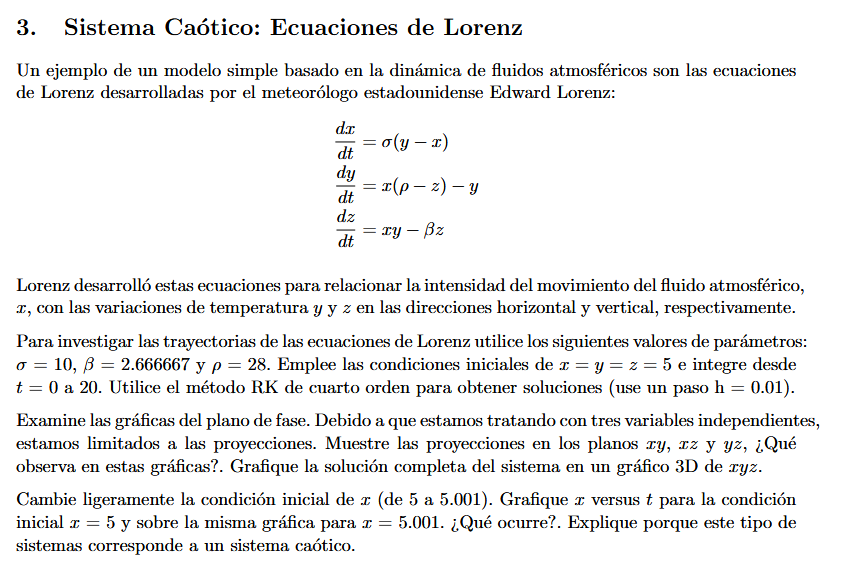

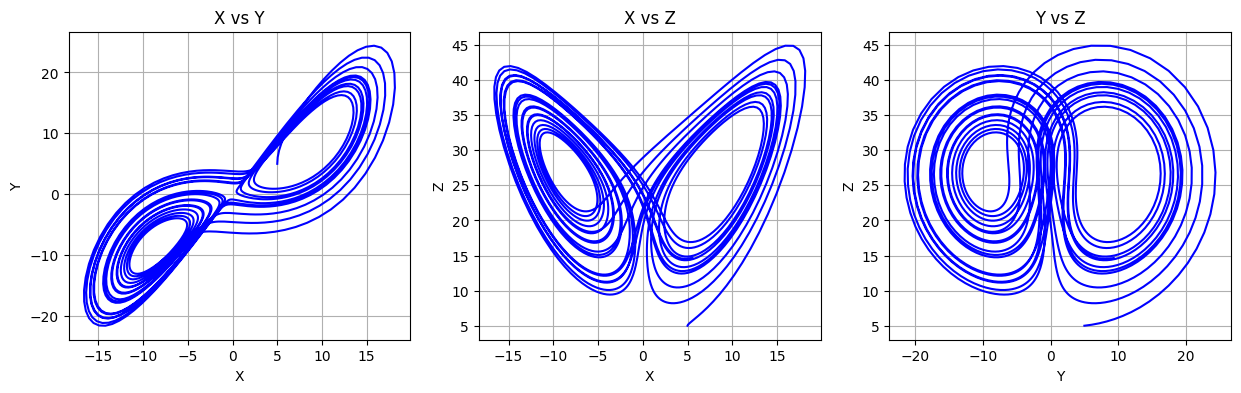

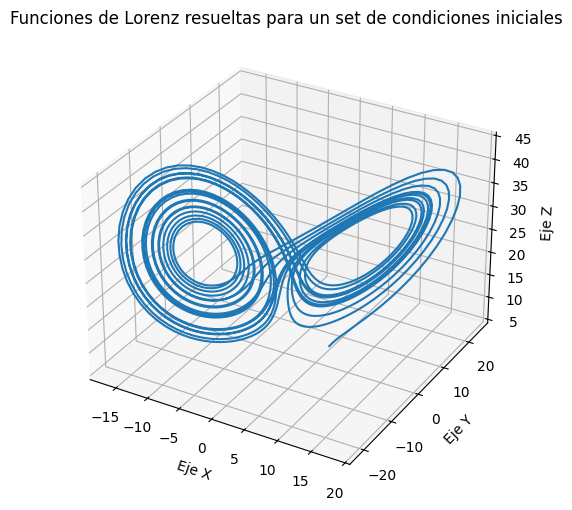

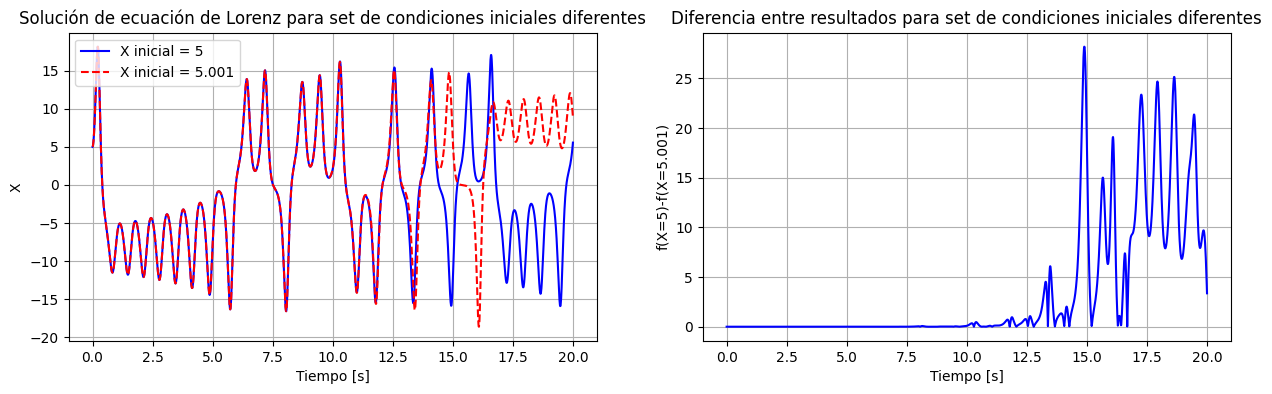

In [ ]:
#constantes
sigma = 10
beta = 2.666667
rho = 28

#valores iniciales
x_inicial = 0 #[s]
x_final = 20 #[s]
y_inicial = np.array([5, 5, 5]) #x, y, z
y_inicial_decimal = np.array([5.001, 5, 5]) #x, y, z
paso = 0.01 #[s]

#funcion a resolver
def funcion(x, y_inicial):
  x = y_inicial[0]
  y = y_inicial[1]
  z = y_inicial[2]

  dx_dt = sigma*(y-x)
  dy_dt = x*(rho-z)-y
  dz_dt = x*y-beta*z
  return np.array([dx_dt, dy_dt, dz_dt])

#solver para este ejercicio
def calcular_parametros(f, xi, yi, xf, paso):
  y_lista = []
  x_lista = []

  while xi < xf:
    y_lista.append(yi)
    x_lista.append(xi)
    yi = rk4(f, xi, yi, paso)
    xi += paso

  return np.array(x_lista), np.array(y_lista)

x_lista, y_lista = calcular_parametros(funcion, x_inicial, y_inicial, x_final, paso)
x_lista, y_lista_decimal = calcular_parametros(funcion, x_inicial, y_inicial_decimal, x_final, paso)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(y_lista[:,0], y_lista[:,1], color='blue')
axes[0].set_title('X vs Y')
axes[0].set_xlabel('X')
axes[0].set_ylabel('Y')
axes[0].grid(True)

axes[1].plot(y_lista[:,0], y_lista[:,2], color='blue')
axes[1].set_title('X vs Z')
axes[1].set_xlabel('X')
axes[1].set_ylabel('Z')
axes[1].grid(True)


axes[2].plot(y_lista[:,1], y_lista[:,2], color='blue')
axes[2].set_title('Y vs Z')
axes[2].set_xlabel('Y')
axes[2].set_ylabel('Z')
axes[2].grid(True)

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')

ax.plot(y_lista[:, 0], y_lista[:, 1], y_lista[:, 2])

ax.set_xlabel('Eje X')
ax.set_ylabel('Eje Y')
ax.set_zlabel('Eje Z')
ax.set_title('Funciones de Lorenz resueltas para un set de condiciones iniciales')
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

axes[0].plot(x_lista, y_lista[:,0], color='blue', label="X inicial = 5")
axes[0].plot(x_lista, y_lista_decimal[:,0], color='red', linestyle="--", label="X inicial = 5.001")
axes[0].set_title('Solución de ecuación de Lorenz para set de condiciones iniciales diferentes')
axes[0].set_xlabel('Tiempo [s]')
axes[0].legend()
axes[0].set_ylabel('X')
axes[0].grid(True)

diferencia_array = np.abs(y_lista_decimal[:, 0] - y_lista[:, 0])

axes[1].plot(x_lista, diferencia_array, color='blue')
axes[1].set_title('Diferencia entre resultados para set de condiciones iniciales diferentes')
axes[1].set_xlabel('Tiempo [s]')
axes[1].set_ylabel('f(X=5)-f(X=5.001)')
axes[1].grid(True)


Lo más importante que se puede visualizar en los gráficos 2D para todos los ejes es la forma distintiva que se genera. En los 3 ejes se crea una forma específica, muy parecido a las alas de una mariposa y ningun punto, a pesar de ser resultados caóticos, parece salirse de este rango. Se podría decir que es estable a pesar que los resultados son impredecibles.

Strogatz (2015) menciona que la fuente principal de este fenomeno y sus peculiaridades son los terminos nolineales que aparecen dentro en las ecuaciones que se están integrando. Estos terminos son x*y y x*z, que a pesar de ser solo dos, son los responsables de generar este fenomeno complejo. A diferencia de las sistemas lineales, dónde existe una proporción establecida que relaciona las entradas y salidas (por ejemplo 2*x o x + y) y que es posible generalizar para encontrar su comportamiento ante diferentes eventos, los sistemas no lineales pueden tener relaciones que pueden variar de maneras desproporcionales ante diferentes situaciones. Por lo tanto su comportamiento no es generalizable. Por ejemplo esta es la razón por la que se tiende a linealizar ecuaciones físicas complejas como el moviento de las olas en el mar al asumir que la altura de la ola es un termino muy pequeño. Al hacerlo podemos extraer un set de ecuaciones predecibles que nos permiten generalizar el comportamiento de este fenomeno, mientras que al utilizar las ecuaciones completas no-linearizadas debemos resolver el conjunto de ecuaciones diferenciales para conocer como se comportará para un set de condiciones específico, que podría ser muy diferente para unas condiciones iniciales similares, como vimos en el ejemplo de la ecuación de lorenz al cambiar x de 5 a 5.001.

Strogatz (2015) tambien menciona que estos fenómenos caóticos tienden a permanecer dentro de cierto rango, atraido a una zona específica, a la que se denomina como atractor extraño. Esto es que lo sucede con el patron reconocible que genera la ecuación de lorenz (alas de una mariposa). Su demostración es matemática compleja, pero la idea principal que los resultados de la ecuacion, a pesar de que los resultados son caóticos e impredecibles, siempre se mantienen en un rango específico muy complejo de cuantificar. Se podría decir que este atractor extraño es simil a por ejemplo, que a pesar de la complejidad y nolinearidad de las interacciones que producen, por ejemplo, un arbol, con todos sus detalles y variabilidad en la posición de las ramas, sus hojas, altura, estos siempre estarán dentro de un rango específico. El arbol siempre será arbol a pesar de la diferencia específica entre sujetos de la misma especie.

 Bibliografía.

 Strogatz, S. H. (2015). Nonlinear dynamics and chaos: With applications to physics, biology, chemistry, and engineering. Westview Press.